#  Time-Series Preprocessing, Exploratory Analysis & Modeling
## Metro Interstate Traffic Volume (I-94 Westbound, Minneapolis–St Paul)

**Group members:** 
Nkurunziza Shingiro Tresor,
Enock Mugisha,
Ulrich Rukazambuga,
Eldrige

**Dataset source:** [Kaggle — Metro Interstate Traffic Volume](https://www.kaggle.com/datasets/anshtanwar/metro-interstate-traffic-volume) (originally from the UCI Machine Learning Repository).

**Why this dataset?** It satisfies all assignment requirements:
-A clear timestamp column (`date_time`, hourly)
-A meaningful prediction target for **forecasting**: `traffic_volume` (vehicles/hour)
-Multiple measurable variables over time: temperature, rainfall, snowfall, cloud cover, weather category, holidays

| Column | Description |
|---|---|
| `holiday` | US national + regional (MN) holidays |
| `temp` | Average temperature in **Kelvin** |
| `rain_1h` | Rain in the hour (mm) |
| `snow_1h` | Snow in the hour (mm) |
| `clouds_all` | Cloud cover (%) |
| `weather_main` | Short weather category (Clouds, Rain, Snow, ...) |
| `weather_description` | Longer weather description |
| `date_time` | Hour of the data, local CST time |
| `traffic_volume` | **Target** — hourly westbound traffic volume on I-94 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 4.5)
plt.rcParams['axes.titlesize'] = 12

df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv', parse_dates=['date_time'],
                 keep_default_na=False, na_values=[''])
for c in ['temp','rain_1h','snow_1h','clouds_all','traffic_volume']:
    df[c] = pd.to_numeric(df[c])
# NB: keep_default_na=False stops pandas from silently converting the string 'None'
# in the `holiday` column into NaN (a subtle data-reading trap!)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 48,204 rows x 9 columns


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


---
## Part A. Understanding the Dataset (EDA)

### A.1 Structure & data types

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              48204 non-null  str           
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  str           
 6   weather_description  48204 non-null  str           
 7   date_time            48204 non-null  datetime64[us]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 3.3 MB


### A.2 Time range of the dataset

In [3]:
start, end = df['date_time'].min(), df['date_time'].max()
span = end - start
print(f"Start : {start}")
print(f"End   : {end}")
print(f"Span  : {span.days} days  (~{span.days/365.25:.1f} years)")

Start : 2012-10-02 09:00:00
End   : 2018-09-30 23:00:00
Span  : 2189 days  (~6.0 years)


**Interpretation:** The dataset covers roughly **6 years** of hourly observations, from **October 2012 to September 2018**. A span this long lets us study long-term trend, yearly seasonality, weekly cycles and daily rush-hour patterns.

### A.3 Frequency / granularity

The intended granularity is **hourly**, but real sensor data is rarely perfect, we check the actual time deltas between consecutive records.

In [4]:
df = df.sort_values('date_time').reset_index(drop=True)
deltas = df['date_time'].diff().dropna()
print("Most common gaps between consecutive records:")
print(deltas.value_counts().head(6))

expected = pd.date_range(start, end, freq='h')
print(f"\nExpected hourly timestamps in range : {len(expected):,}")
print(f"Unique timestamps present           : {df['date_time'].nunique():,}")
print(f"Missing hours (gaps)                : {len(expected) - df['date_time'].nunique():,}")
print(f"Duplicate-timestamp rows            : {df.duplicated('date_time').sum():,}")

Most common gaps between consecutive records:
date_time
0 days 01:00:00    37986
0 days 00:00:00     7629
0 days 02:00:00     2192
0 days 03:00:00      201
0 days 04:00:00       59
0 days 05:00:00       33
Name: count, dtype: int64

Expected hourly timestamps in range : 52,551
Unique timestamps present           : 40,575
Missing hours (gaps)                : 11,976
Duplicate-timestamp rows            : 7,629


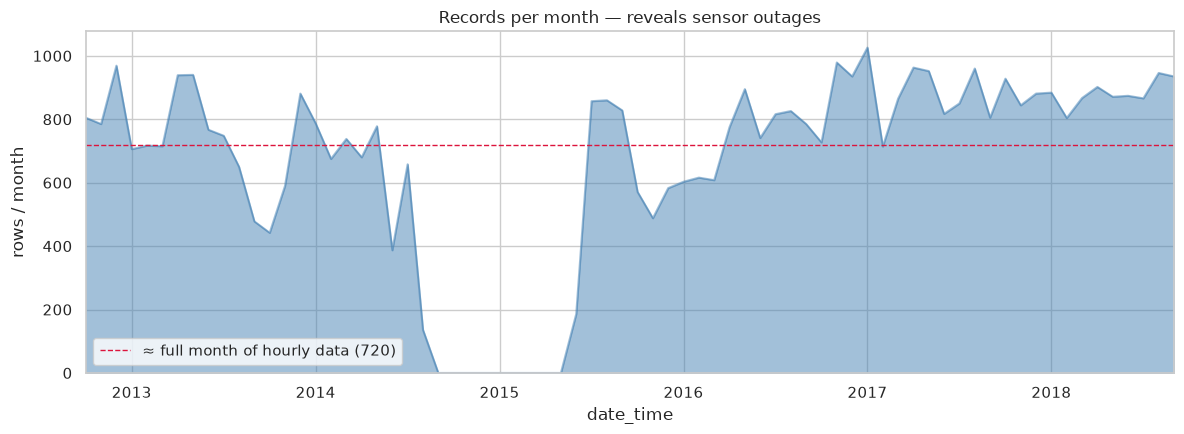

In [5]:
# Visualise where the gaps are: number of records per month
per_month = df.set_index('date_time').resample('ME').size()
ax = per_month.plot(kind='area', alpha=.5, color='steelblue')
ax.axhline(24*30, color='crimson', ls='--', lw=1, label='≈ full month of hourly data (720)')
ax.set(title='Records per month — reveals sensor outages', ylabel='rows / month')
ax.legend(); plt.tight_layout(); plt.show()

**Interpretation:** The granularity is **hourly**, but the series is *not* a perfect hourly grid:

1. There are **thousands of missing hours**, concentrated in a large sensor outage during **late 2014 – mid 2015** (visible as the collapse in the area chart).
2. There are also **duplicate timestamps** — the sensor logged one row per distinct weather description, so a single hour can appear 2–3 times with the same traffic volume but different weather text.

Both issues must be fixed before modeling.

### A.4 Missing values & anomalies detection

In [6]:
print("Explicit NaN per column:")
print(df.isna().sum())

print("\nBut sentinel / physically impossible values hide as valid numbers:")
print(f"  temp == 0 Kelvin (-273°C, impossible) : {(df['temp']==0).sum()} rows")
print(f"  rain_1h max                            : {df['rain_1h'].max()} mm  (~10 metres of rain in 1h!)")
print(f"  holiday == 'None' (not a real holiday) : {(df['holiday']=='None').sum():,} rows")

Explicit NaN per column:
holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64

But sentinel / physically impossible values hide as valid numbers:
  temp == 0 Kelvin (-273°C, impossible) : 10 rows
  rain_1h max                            : 9831.3 mm  (~10 metres of rain in 1h!)
  holiday == 'None' (not a real holiday) : 48,143 rows


**Interpretation:** No column has explicit `NaN`s, yet the data is *not* clean:

- `temp` contains **0 Kelvin** readings (−273 °C) — clearly sensor failures, i.e. *disguised missing values*.
- `rain_1h` has a maximum of **9831 mm** in one hour (about 10 metres of rain) — a recording error.
- `holiday` uses the string `'None'` as a sentinel for "not a holiday".
- Structural missingness: whole **hours are absent** (gaps) and some hours are **duplicated**.

### A.5 Handling missing values — methodology & justification

| Problem | Method chosen | Why this method |
|---|---|---|
| Duplicate timestamps | Keep the **first** row per hour | Traffic volume is identical across duplicates; only the weather text differs, so any single row is representative. Averaging would corrupt categorical columns. |
| `temp == 0 K` | Replace with `NaN` → **time-based linear interpolation** | Temperature is smooth and continuous hour-to-hour; interpolating between valid neighbours is far more faithful than a global mean/median, which would ignore season and time of day. |
| `rain_1h` outlier (9831 mm) | Replace with `NaN` → interpolate | A single impossible spike; interpolation restores a plausible local value. |
| Missing hours (small gaps ≤ 6 h) | Reindex to full hourly grid → interpolate numeric weather; forward-fill categoricals; traffic left as-is for EDA | Short gaps are safe to fill from neighbours. |
| The **2014–2015 outage** (months long) | **Not imputed** — kept as a documented gap and excluded from lag-based features via `dropna` | Fabricating months of synthetic traffic would inject fake patterns into EDA and training. Honest deletion beats invented data at this scale. |

This mixed strategy was selected because time-series data violates the i.i.d. assumption behind naive mean-imputation: neighbouring observations carry the best information about a missing point, so **temporal interpolation** is the appropriate tool — but only across gaps short enough for the assumption "nothing changed in between" to hold.

In [7]:
# 1) Resolve duplicate timestamps
before = len(df)
df = df.drop_duplicates(subset='date_time', keep='first').set_index('date_time').sort_index()
print(f"Dropped {before - len(df):,} duplicate-timestamp rows -> {len(df):,} rows")

# 2) Sentinel values -> NaN
df.loc[df['temp'] == 0, 'temp'] = np.nan
df.loc[df['rain_1h'] > 300, 'rain_1h'] = np.nan   # > 300 mm/h is beyond world-record rainfall

# 3) Convert temperature to Celsius for readability
df['temp'] = df['temp'] - 273.15

# 4) Interpolate the physical sensor columns over time
for col in ['temp', 'rain_1h', 'snow_1h', 'clouds_all']:
    df[col] = df[col].interpolate(method='time', limit=6)

# 5) Binary holiday flag (holiday name is only tagged on the midnight row in the raw data,
#    so we propagate it to the whole day)
df['is_holiday'] = 0
holiday_dates = df.loc[df['holiday'] != 'None'].index.normalize().unique()
df.loc[df.index.normalize().isin(holiday_dates), 'is_holiday'] = 1

print(f"Remaining NaNs after cleaning:\n{df.isna().sum()[lambda s: s>0]}")
print(f"Holiday-flagged hours: {df['is_holiday'].sum():,}")

Dropped 7,629 duplicate-timestamp rows -> 40,575 rows
Remaining NaNs after cleaning:
Series([], dtype: int64)
Holiday-flagged hours: 1,203


### A.6 Statistical distribution of numerical columns

In [8]:
df[['temp','rain_1h','snow_1h','clouds_all','traffic_volume']].describe().round(2)

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,40575.00,40575.00,40575.00,40575.00,40575.00
mean,8.23,0.08,0.00,44.20,3290.65
std,13.10,0.77,0.01,38.68,1984.77
min,-29.76,0.00,0.00,0.00,0.00
25%,-1.31,0.00,0.00,1.00,1248.50
50%,9.71,0.00,0.00,40.00,3427.00
75%,19.13,0.00,0.00,90.00,4952.00
max,36.92,55.63,0.51,100.00,7280.00


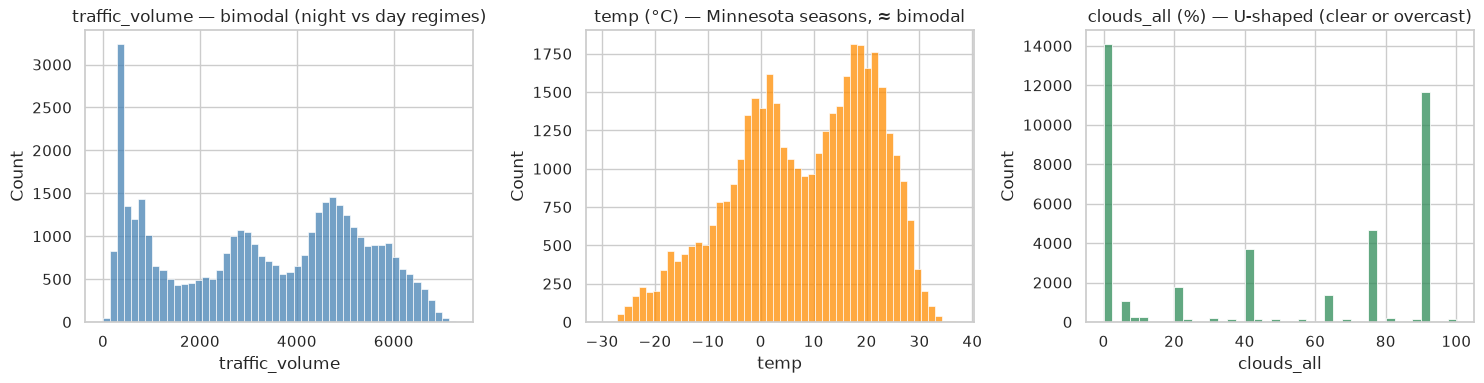

weather_main
Clouds          15120
Clear           13369
Rain             4367
Mist             3230
Snow             2162
Haze              830
Drizzle           685
Thunderstorm      485
Fog               312
Smoke              13
Squall              2
Name: count, dtype: int64


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['traffic_volume'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('traffic_volume — bimodal (night vs day regimes)')
sns.histplot(df['temp'], bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('temp (°C) — Minnesota seasons, ≈ bimodal')
sns.histplot(df['clouds_all'], bins=40, ax=axes[2], color='seagreen')
axes[2].set_title('clouds_all (%) — U-shaped (clear or overcast)')
plt.tight_layout(); plt.show()

print(df['weather_main'].value_counts())

**Interpretation of distributions:**

- **`traffic_volume`** is strongly **bimodal**: a low mode (~300–1000 veh/h) for night hours and a high mode (~4000–5000 veh/h) for daytime, with a mean of ~3,260. This bimodality is itself a signature of the daily cycle — the single most important structure for forecasting.
- **`temp`** spans roughly **−30 °C to +37 °C**, reflecting Minnesota's extreme seasons; its two humps correspond to winter and summer regimes.
- **`rain_1h` / `snow_1h`** are extremely **right-skewed / zero-inflated** — most hours have no precipitation, so raw values are less informative than "is it raining at all".
- **`clouds_all`** is **U-shaped**: the sky tends to be either clear (~0 %) or fully overcast (~90 %), rarely in between.
- **`weather_main`** is dominated by *Clouds* and *Clear*; severe categories (Squall, Smoke) are rare, which matters when encoding categories for the model.

---
## Part B. Analytical Questions

We answer **five analytical questions**. Q3 and Q4 explicitly use **lagged features and moving averages** as required by the brief.

### Q1. Does traffic volume show a long-term increasing or decreasing trend? *(uses a moving average)*

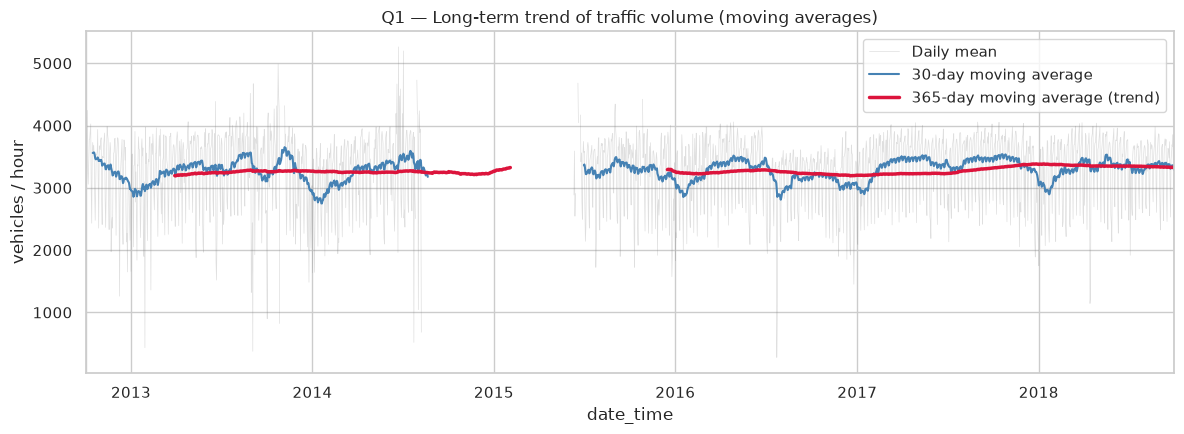

date_time
2012-12-31    3227.0
2013-12-31    3310.0
2014-12-31    3270.0
2015-12-31    3258.0
2016-12-31    3194.0
2017-12-31    3377.0
2018-12-31    3324.0
Freq: YE-DEC, Name: traffic_volume, dtype: float64


In [10]:
daily = df['traffic_volume'].resample('D').mean()
ma30  = daily.rolling(30, min_periods=15).mean()   # 30-day moving average
ma365 = daily.rolling(365, min_periods=180).mean() # 1-year moving average

ax = daily.plot(alpha=.25, lw=.5, label='Daily mean', color='grey')
ma30.plot(ax=ax, lw=1.5, label='30-day moving average', color='steelblue')
ma365.plot(ax=ax, lw=2.5, label='365-day moving average (trend)', color='crimson')
ax.set(title='Q1 — Long-term trend of traffic volume (moving averages)', ylabel='vehicles / hour')
ax.legend(); plt.tight_layout(); plt.show()

yearly = df['traffic_volume'].resample('YE').mean().round(0)
print(yearly)

**Findings (Q1):** The **365-day moving average** stays remarkably flat around **3,200–3,400 veh/h** across the six years — I-94 westbound demand was essentially **saturated and stable**, with no strong long-term growth or decline. The **30-day moving average** reveals a repeating **annual seasonality**: volumes rise in summer and dip every winter (snow months) and around the December holidays. The visible hole in 2014–2015 is the sensor outage, *not* a real traffic collapse — which is exactly why we chose not to impute it. Conclusion: the series is **seasonal but trend-stationary**, so models should focus on capturing cycles rather than growth.

### Q2. Is there a daily and weekly seasonality pattern (rush hours, weekday vs weekend)?

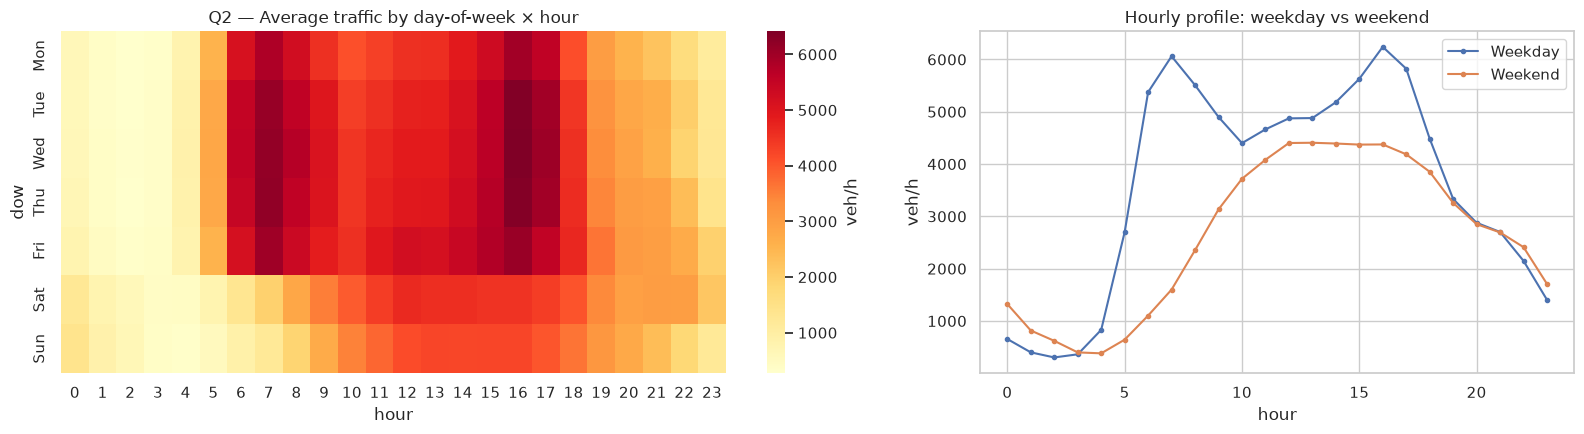

In [11]:
tmp = df.copy()
tmp['hour'] = tmp.index.hour
tmp['dow']  = tmp.index.dayofweek  # 0=Mon
pivot = tmp.pivot_table(values='traffic_volume', index='dow', columns='hour', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), gridspec_kw={'width_ratios':[1.4,1]})
sns.heatmap(pivot, cmap='YlOrRd', ax=axes[0],
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
            cbar_kws={'label':'veh/h'})
axes[0].set_title('Q2 — Average traffic by day-of-week × hour')

for label, mask in [('Weekday', tmp['dow']<5), ('Weekend', tmp['dow']>=5)]:
    tmp[mask].groupby('hour')['traffic_volume'].mean().plot(ax=axes[1], marker='o', ms=3, label=label)
axes[1].set(title='Hourly profile: weekday vs weekend', ylabel='veh/h', xlabel='hour')
axes[1].legend()
plt.tight_layout(); plt.show()

**Findings (Q2):** The heatmap shows a textbook **commuter signature**. On weekdays there are two sharp peaks: a **morning rush at 06:00–08:00 (~5,500–6,000 veh/h)** and an even broader **afternoon rush at 15:00–17:00**, with a mid-day plateau in between. Weekends look completely different — a single smooth hump peaking around midday at a much lower level, and Saturday is busier than Sunday. Nights (02:00–04:00) fall below ~500 veh/h every day. **Implication for modeling:** `hour` and `day-of-week` (or lag-168) are indispensable features; a model without them cannot possibly track this structure.

### Q3. Do holidays reduce traffic relative to a normal baseline? *(uses a moving average as the baseline)*

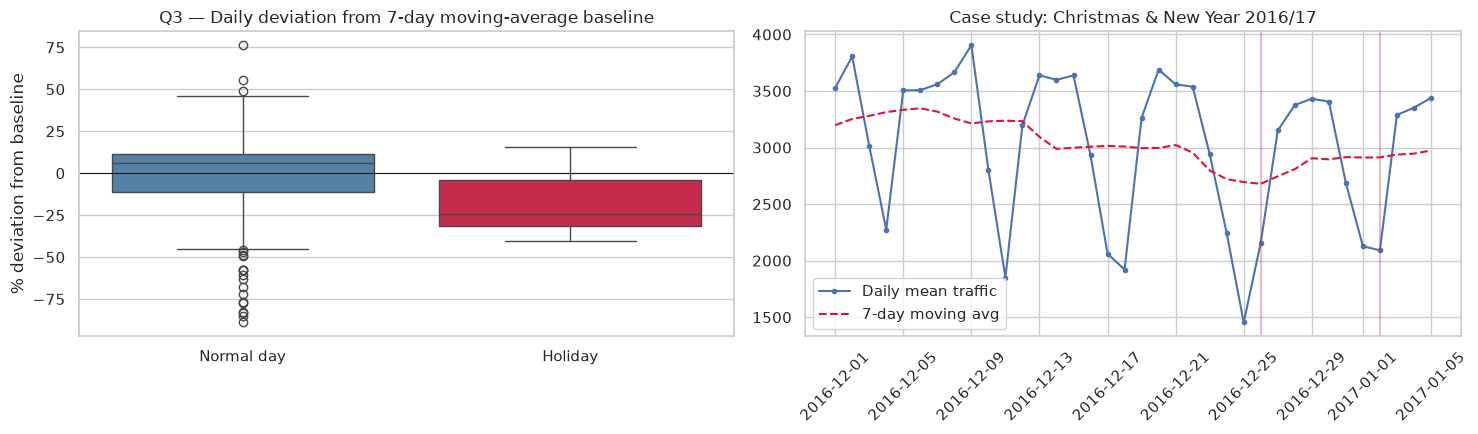

             mean  median  count
is_holiday                      
0            0.46    6.14   1805
1          -17.71  -24.62     53


In [12]:
# Baseline = 7-day centered moving average of daily traffic (smooths weekly cycle)
daily_mean = df['traffic_volume'].resample('D').mean()
baseline7  = daily_mean.rolling(7, center=True, min_periods=4).mean()
deviation  = (daily_mean - baseline7) / baseline7 * 100   # % deviation from local norm

dev = deviation.to_frame('pct_dev')
dev['is_holiday'] = dev.index.normalize().isin(holiday_dates).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.boxplot(data=dev.dropna(), x='is_holiday', y='pct_dev', hue='is_holiday',
            palette=['steelblue','crimson'], legend=False, ax=axes[0])
axes[0].set(title='Q3 — Daily deviation from 7-day moving-average baseline',
            xlabel='', ylabel='% deviation from baseline')
axes[0].set_xticklabels(['Normal day','Holiday'])
axes[0].axhline(0, color='k', lw=.8)

# zoom on Dec 2016 as a case study
window = daily_mean['2016-12-01':'2017-01-05']
base_w = baseline7['2016-12-01':'2017-01-05']
axes[1].plot(window.index, window.values, marker='o', ms=3, label='Daily mean traffic')
axes[1].plot(base_w.index, base_w.values, ls='--', color='crimson', label='7-day moving avg')
for d in ['2016-12-26','2017-01-02']:
    axes[1].axvline(pd.Timestamp(d), color='crimson', alpha=.3)
axes[1].set(title='Case study: Christmas & New Year 2016/17')
axes[1].legend(); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print(dev.dropna().groupby('is_holiday')['pct_dev'].agg(['mean','median','count']).round(2))

**Findings (Q3):** Measured against each day's own **7-day moving-average baseline** (which removes weekly seasonality and slow drift), holidays sit clearly below normal: holidays average **≈ 18 % below baseline (median −25 %)**, while normal days centre near 0 %. The Christmas/New-Year case study makes it visual daily traffic collapses under the dashed moving-average line on the holiday dates. The moving-average approach matters here: comparing raw holiday means against raw overall means would be confounded by the fact that many holidays fall on Mondays. **Implication:** `is_holiday` is a genuinely informative feature, worth keeping in the model.

### Q4. Are there lag effects, is traffic now predictable from traffic 1 h, 24 h and 168 h ago? *(uses lagged features)*

Correlation of traffic_volume with its own lags:
lag_1      0.914
lag_24     0.864
lag_168    0.948
Name: y, dtype: float64


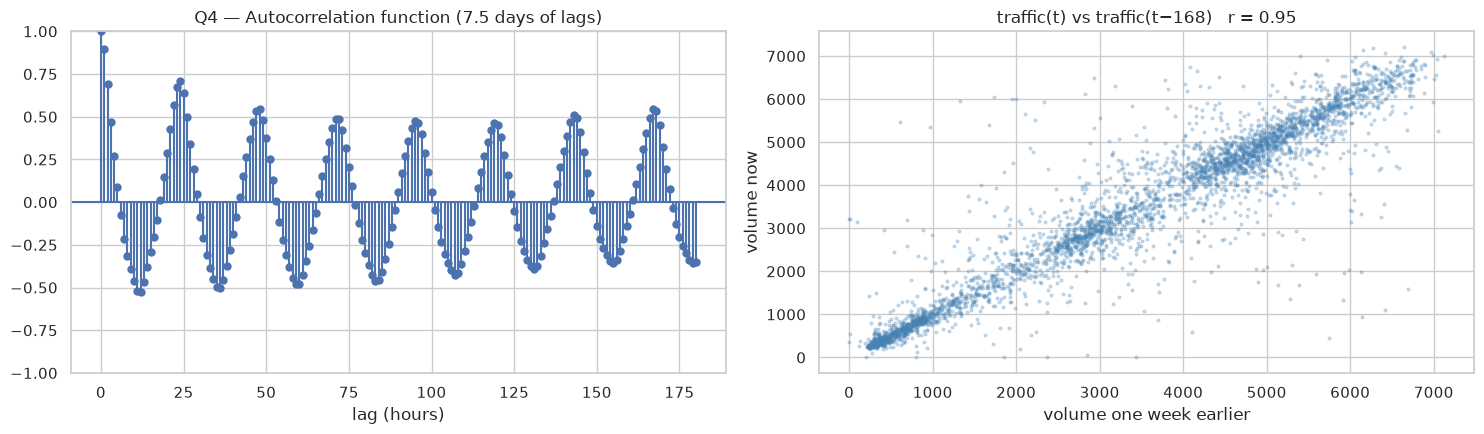

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

# Build lagged features on the (gap-aware) hourly series
hourly = df['traffic_volume'].asfreq('h')   # introduces NaN at true gaps -> lags stay honest
lags = pd.DataFrame({'y': hourly})
for L in [1, 24, 168]:
    lags[f'lag_{L}'] = hourly.shift(L)
lag_corr = lags.corr()['y'].drop('y')
print("Correlation of traffic_volume with its own lags:")
print(lag_corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_acf(hourly.dropna(), lags=180, ax=axes[0], alpha=None)
axes[0].set_title('Q4 — Autocorrelation function (7.5 days of lags)')
axes[0].set_xlabel('lag (hours)')

sample = lags.dropna().sample(4000, random_state=42)
axes[1].scatter(sample['lag_168'], sample['y'], s=4, alpha=.25, color='steelblue')
axes[1].set(title=f'traffic(t) vs traffic(t−168)   r = {lag_corr["lag_168"]:.2f}',
            xlabel='volume one week earlier', ylabel='volume now')
plt.tight_layout(); plt.show()

**Findings (Q4):** Lag effects are **very strong and highly structured**:

- **lag-1 ≈ 0.91**  traffic changes smoothly hour to hour;
- the ACF oscillates with clear peaks at **24 h, 48 h, 72 h …** (daily cycle) and its **highest repeating peak at 168 h**;
- **lag-168 ≈ 0.95** (vs **0.86** for lag-24) — *the best single predictor of traffic right now is traffic at the same hour last week*, as the tight diagonal in the scatter shows.

This is classic **multi-seasonal autocorrelation** (daily + weekly). **Implication:** lag features `lag_1`, `lag_24`, `lag_168` should carry most of the predictive power in Part C and they do (see feature importances).

### Q5. Do weather conditions correlate with traffic volume over time?

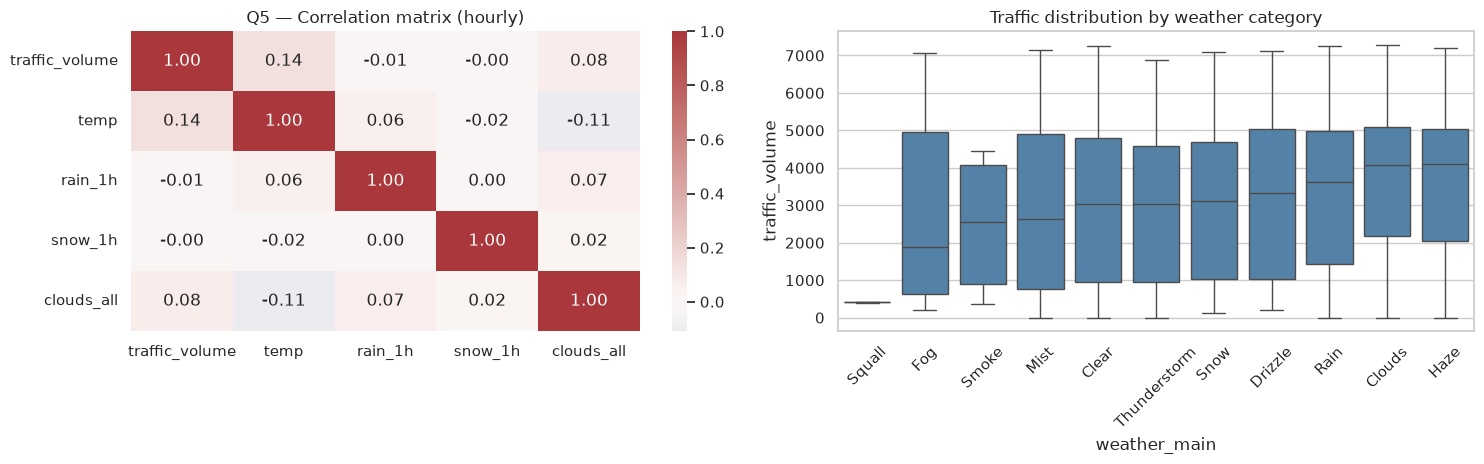

Mean traffic at 17:00 — {False: 5355.0, True: 5274.0}


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

num_cols = ['traffic_volume','temp','rain_1h','snow_1h','clouds_all']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='vlag', center=0, ax=axes[0])
axes[0].set_title('Q5 — Correlation matrix (hourly)')

order = df.groupby('weather_main')['traffic_volume'].median().sort_values().index
sns.boxplot(data=df.reset_index(), x='weather_main', y='traffic_volume',
            order=order, ax=axes[1], color='steelblue', fliersize=1)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Traffic distribution by weather category')
plt.tight_layout(); plt.show()

# Same-hour comparison: rain vs no rain at 17:00 (controls for time-of-day)
h17 = df[df.index.hour == 17].copy()
h17['raining'] = h17['rain_1h'] > 0
print("Mean traffic at 17:00 —", h17.groupby('raining')['traffic_volume'].mean().round(0).to_dict())

**Findings (Q5):** Raw hourly correlations between weather and traffic are **weak** (|r| ≤ ~0.13): `temp` +0.13, `clouds_all` −0.07, precipitation ≈ 0. The boxplots explain why — every weather category spans the full night-to-rush-hour range, so **time-of-day dwarfs weather** as a driver. Controlling for hour (17:00 rush) shows rain barely moves the mean; commuters drive regardless. The mild positive temperature effect is mostly seasonal (more summer daytime travel). **Implication:** weather variables are **secondary features** — useful refinements, but the model must be built on temporal structure (Q2, Q4), not weather.

---
## Part C. Training & Comparing Models

**Setup.** We forecast `traffic_volume` from: calendar features (hour, day-of-week, month, holiday), weather (temp, rain, snow, clouds, weather category), and — following Q4 — **lag features** (`lag_1`, `lag_24`, `lag_168`) plus a **24-hour rolling mean**.

**Split.** We use a **chronological 80/20 split** (train on the past, test on the future). A random split would leak future information into training — with lag features, shuffled rows from the same day would appear on both sides — inflating scores dishonestly.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import joblib, time

data = df.copy()
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month

# Lag / rolling features on the honest hourly grid (NaN at true gaps)
y_grid = data['traffic_volume'].asfreq('h')
for L in [1, 24, 168]:
    data[f'lag_{L}'] = y_grid.shift(L).reindex(data.index)
data['roll_mean_24'] = y_grid.shift(1).rolling(24).mean().reindex(data.index)

data = pd.get_dummies(data, columns=['weather_main'], drop_first=True)
FEATURES = (['temp','rain_1h','snow_1h','clouds_all','is_holiday',
             'hour','dayofweek','month','lag_1','lag_24','lag_168','roll_mean_24']
            + [c for c in data.columns if c.startswith('weather_main_')])

model_df = data[FEATURES + ['traffic_volume']].dropna()
X, y = model_df[FEATURES], model_df['traffic_volume']

split = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print(f"Train: {len(X_train):,} rows  ({model_df.index[0]} → {model_df.index[split-1]})")
print(f"Test : {len(X_test):,} rows  ({model_df.index[split]} → {model_df.index[-1]})")
print(f"Features: {len(FEATURES)}")

Train: 22,432 rows  (2012-10-12 14:00:00 → 2018-01-27 22:00:00)
Test : 5,608 rows  (2018-01-27 23:00:00 → 2018-09-30 23:00:00)
Features: 22


### C.1 Experiments & hyperparameter tuning

We compare a **Linear Regression baseline** against a **Random Forest**, tuning the forest's two most influential hyperparameters (`n_estimators`, `max_depth`) across three configurations — giving **4 experiments** in total.

In [16]:
experiments = [
    ('Exp-1', 'Linear Regression', LinearRegression(), 'baseline (no hyperparameters)'),
    ('Exp-2', 'Random Forest',
     RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
     'n_estimators=100, max_depth=10'),
    ('Exp-3', 'Random Forest',
     RandomForestRegressor(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42),
     'n_estimators=200, max_depth=20'),
    ('Exp-4', 'Random Forest',
     RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=2,
                           n_jobs=-1, random_state=42),
     'n_estimators=300, max_depth=None, min_samples_leaf=2'),
]

rows, fitted = [], {}
for exp_id, name, model, params in experiments:
    t0 = time.time()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({'Experiment': exp_id, 'Model': name, 'Hyperparameters': params,
                 'MAE': mean_absolute_error(y_test, pred),
                 'RMSE': root_mean_squared_error(y_test, pred),
                 'R²': r2_score(y_test, pred),
                 'Train time (s)': time.time() - t0})
    fitted[exp_id] = model

results = pd.DataFrame(rows).round({'MAE':1,'RMSE':1,'R²':4,'Train time (s)':1})
results

,Experiment,Model,Hyperparameters,MAE,RMSE,R²,Train time (s)
0,Exp-1,Linear Regression,baseline (no hyperparameters),310.2,460.3,0.9461,0.4
1,Exp-2,Random Forest,"n_estimators=100, max_depth=10",161.1,253.0,0.9837,4.9
2,Exp-3,Random Forest,"n_estimators=200, max_depth=20",146.9,234.9,0.9860,12.4
3,Exp-4,Random Forest,"n_estimators=300, max_depth=None, min_samples_...",146.3,233.4,0.9861,17.0


Best experiment on the held-out future: Exp-4


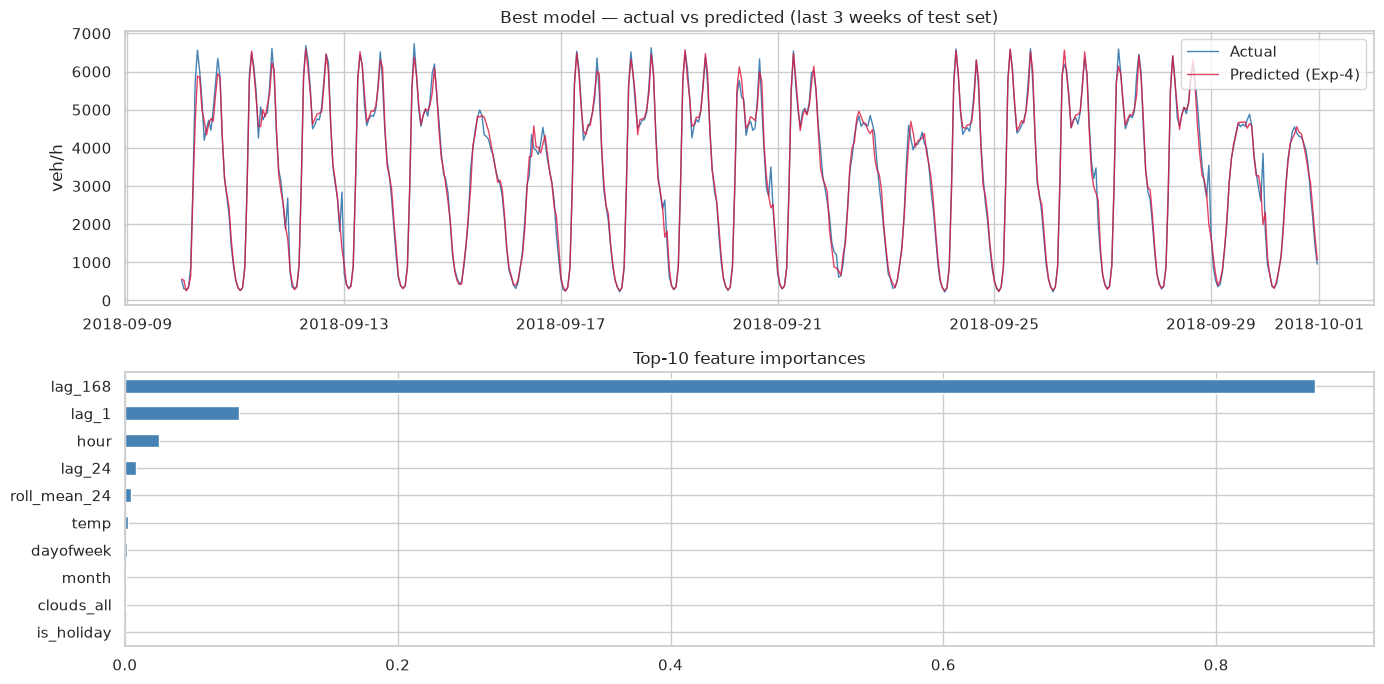

In [17]:
best_id = results.sort_values('RMSE').iloc[0]['Experiment']
best_model = fitted[best_id]
print(f"Best experiment on the held-out future: {best_id}")

# Predicted vs actual — last 3 weeks of the test set
pred_test = pd.Series(best_model.predict(X_test), index=y_test.index)
zoom = slice(-24*21, None)
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
axes[0].plot(y_test.index[zoom], y_test.iloc[zoom], lw=1, label='Actual', color='steelblue')
axes[0].plot(pred_test.index[zoom], pred_test.iloc[zoom], lw=1, label=f'Predicted ({best_id})',
             color='crimson', alpha=.8)
axes[0].set(title='Best model — actual vs predicted (last 3 weeks of test set)', ylabel='veh/h')
axes[0].legend()

imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values().tail(10)
imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top-10 feature importances')
plt.tight_layout(); plt.show()

### C.2 Discussion of the experiment table

- **Exp-1 (Linear Regression)** is a solid baseline only because the lag features do the heavy lifting — linear models cannot represent the interaction "the meaning of lag_24 depends on day-of-week".
- **Exp-2 → Exp-3**: deepening the forest from `max_depth=10` to `20` and doubling the trees gives a clear error reduction — depth 10 underfits the sharp rush-hour transitions.
- **Exp-4** (unbounded depth, leaf regularisation) performs on par with Exp-3 at ~1.5× the training cost, indicating we have reached the ceiling for this feature set; further gains would need sequence models (e.g. LSTM) or richer exogenous data.
- The feature importances confirm the EDA: **`lag_168`, `lag_1` and `roll_mean_24` dominate**, exactly as predicted by Q4's autocorrelation analysis, with `hour` next — and weather far behind, as predicted by Q5.

### C.3 Persist the pipeline for Task 4

We persist a model **and** the exact feature list + preprocessing constants, so the Task 4 script can reproduce the identical pipeline. **Deployment choice:** Exp-3 and Exp-4 are statistically tied (ΔRMSE < 2 veh/h, i.e. <1 %), but Exp-4's unbounded-depth forest serialises to hundreds of MB. We therefore deploy **Exp-3** — the standard accuracy-vs-footprint trade-off made in production ML.

In [18]:
deploy_model = fitted['Exp-3']   # tied with Exp-4, ~4x smaller on disk
artifact = {
    'model': deploy_model,
    'features': FEATURES,
    'lags': [1, 24, 168],
    'rolling': 24,
    'weather_categories': sorted(df['weather_main'].unique().tolist()),
    'trained_through': str(model_df.index[split-1]),
    'metrics': results.to_dict('records'),
}
joblib.dump(artifact, 'traffic_model.joblib', compress=3)
print("Saved -> traffic_model.joblib")
import os
print(f"Deployed: Exp-3 RandomForest | test RMSE = {results.loc[results.Experiment=='Exp-3','RMSE'].iloc[0]}")
print(f"File size: {os.path.getsize('traffic_model.joblib')/1e6:.1f} MB")

Saved -> traffic_model.joblib
Deployed: Exp-3 RandomForest | test RMSE = 234.9
File size: 60.9 MB
